In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

## Force equation for a fibrin fiber represented by a Worm-Like Chain:

$F(l) = A*[\frac{1}{4}(\frac{1}{(1-\frac{l}{l_m})^2})-\frac{1}{4} + \frac{l}{l_m}] - \frac{k_p}{l^2}$

And

$F(\epsilon) = \frac{N*K_b*T}{l_p}*[\frac{1}{4}(\frac{1}{(1-(\frac{\epsilon\cdot{l_0}+l_0}{l_m}))^2})-\frac{1}{4} + \frac{\epsilon\cdot{l_0}+l_0}{l_m}] - \frac{k_p}{(\epsilon\cdot{l_0}+l_0)**2)}$

Where:
A = Weighting parameter (includes Temperature, persistence length, Number of links, and Boltzman Constant)

$A = \frac{N*K_b*T}{l_p}$ 

F = Force produced by stretching fiber

l = length of fiber

l_m = Maximum length of fiber (Including Stretch)

k_p = Repulsion Constant

x = l/l_m

## Results From Parameter Finding

### Unligated Fibrin Fibers:

A = 3.3459107468762793e-09

lm = 1.85471728735441e-05

kp = 5.1052567213669867e-20

### Ligated Fibrin Fibers:

A = 2.256957525770432e-09

lm = 1.6791861497133124e-05

kp = 3.2435785114761894e-20

## Parameter Finding for Unligated Fibrin Fibers

### Experimental Data Collected From Houser Paper

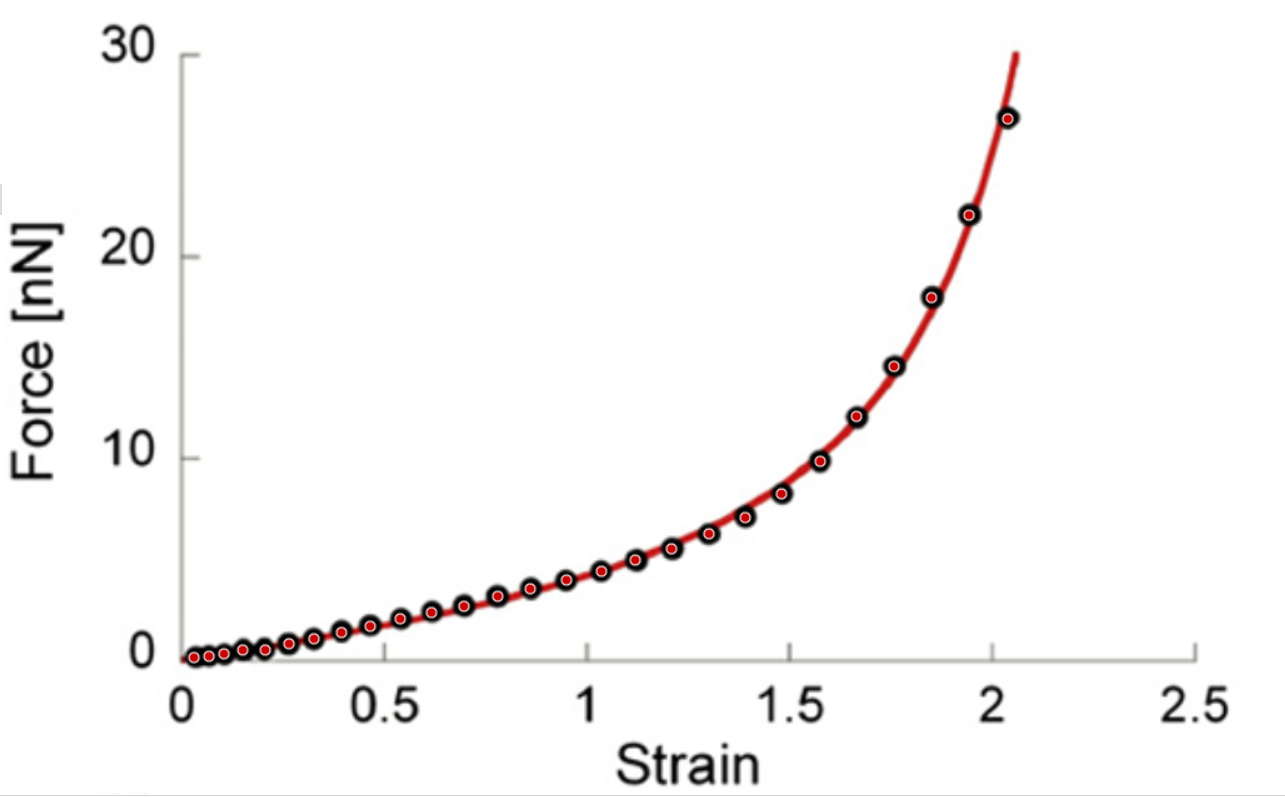

### Curve Fitting Using Least Squares Approximation

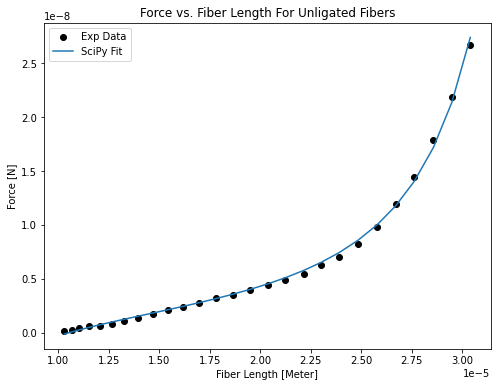

Unligated Parameters:
A = 3.2265438863137044e-09
lm = 3.693568656134975e-05
kp = 1.8696547567965926e-19


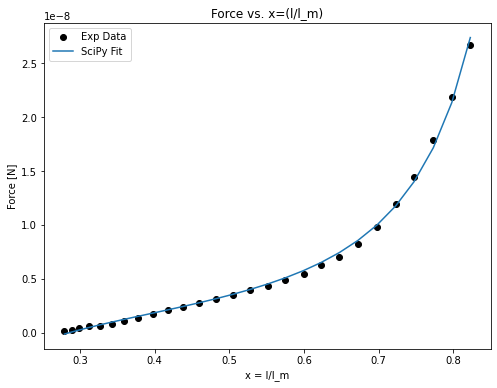

In [8]:
#Unligated Fibers

def f_l_Pow(l,A,l_m,k_p):
    return A*((1/4)*(1-(l/l_m))**(-2)-(1/4)+(l/l_m)) - (k_p/(l**2))
def f_x_Pow(x,A,l_m,k_p):
    return A*((1/4)*(1-(x))**(-2)-(1/4)+(x)) - (k_p/((x*l_m)**2))
       
Len_Data = np.array([[0.000010305810397553517, 1.8106213172223922e-10],
[0.000010672782874617739, 2.39800104423072e-10],
[0.000011039755351681958, 4.204892966360933e-10],
[0.000011498470948012234, 6.006190795852975e-10],
[0.000012048929663608564, 5.972626240023954e-10],
[0.000012660550458715597, 8.374356679346656e-10],
[0.00001327217125382263, 1.0776087118669423e-9],
[0.000013944954128440366, 1.378384426046102e-9],
[0.000014678899082568809, 1.739762810472151e-9],
[0.000015412844036697248, 2.101141194898187e-9],
[0.00001617737003058104, 2.4013574998135296e-9],
[0.000016972477064220186, 2.7623629447303674e-9],
[0.00001779816513761468, 3.184157529648697e-9],
[0.000018623853211009176, 3.544976504810926e-9],
[0.000019480122324159025, 3.966584619974643e-9],
[0.000020366972477064223, 4.388006265383755e-9],
[0.000021223241590214068, 4.931565600059671e-9],
[0.00002214067278287462, 5.4747519952263785e-9],
[0.000022996941896024468, 6.262213768926681e-9],
[0.00002391437308868502, 7.049302603117779e-9],
[0.000024831804281345567, 8.202245095845456e-9],
[0.000025779816513761472, 9.84280599686731e-9],
[0.000026697247706422023, 1.1971358245692547e-8],
[0.000027614678899082575, 1.4465764153054376e-8],
[0.000028562691131498476, 1.7874617737003056e-8],
[0.000029480122324159024, 2.189341388826732e-8],
[0.000030397553516819575, 2.670489296636085e-8]])

Len_Data_Fit = Len_Data*(1e+9); #Increasing the magnitude of the data for the curve fitter (Helps with error)

alpha_Pow = optimize.curve_fit(f_l_Pow, xdata = Len_Data_Fit[:,0] , ydata = Len_Data_Fit[:,1],p0 = [3,4e+4,1e+7])[0]; # Fit curve using least squares method

force_exp,ax = plt.subplots(1,1,figsize=(8,6))                          #plot the curve and the experimental data
plt.title("Force vs. Fiber Length For Unligated Fibers")
ax.set_xlabel("Fiber Length [Meter]")
ax.set_ylabel("Force [N]")
plt.scatter(Len_Data[:,0],Len_Data[:,1],color = 'black',label = 'Exp Data')
plt.plot(Len_Data[:,0], f_l_Pow(Len_Data[:,0],alpha_Pow[0]*1e-9,alpha_Pow[1]*1e-9,alpha_Pow[2]*1e-27),label='SciPy Fit') #Correct the magnitudes of the parameters
ax.legend()
plt.show()

print('Unligated Parameters:')
A = alpha_Pow[0]*1e-9,
print('A = '+str(alpha_Pow[0]*1e-9))
l_m = alpha_Pow[1]*1e-9,
print('lm = '+str(alpha_Pow[1]*1e-9))
k_p = alpha_Pow[2]*1e-27,
print('kp = '+str(alpha_Pow[2]*1e-27))

#Define the function in terms of force vs x = l/lm
x_vect = Len_Data[:,0]/l_m;

x_data = np.vstack((x_vect,Len_Data[:,1]))

force_x,bx = plt.subplots(1,1,figsize=(8,6))                          
plt.title("Force vs. x=(l/l_m)")
bx.set_xlabel("x = l/l_m")
bx.set_ylabel("Force [N]")
plt.scatter(x_data[:][0],Len_Data[:,1],color = 'black',label = 'Exp Data')
plt.plot(x_data[:][0], f_x_Pow(x_data[:][0],A,l_m,k_p),label='SciPy Fit') #Correct the magnitudes of the parameters
bx.legend()
plt.show()

## Parameter Finding for Ligated Fibrin Fibers

### Experimental Data Collected From Houser Paper

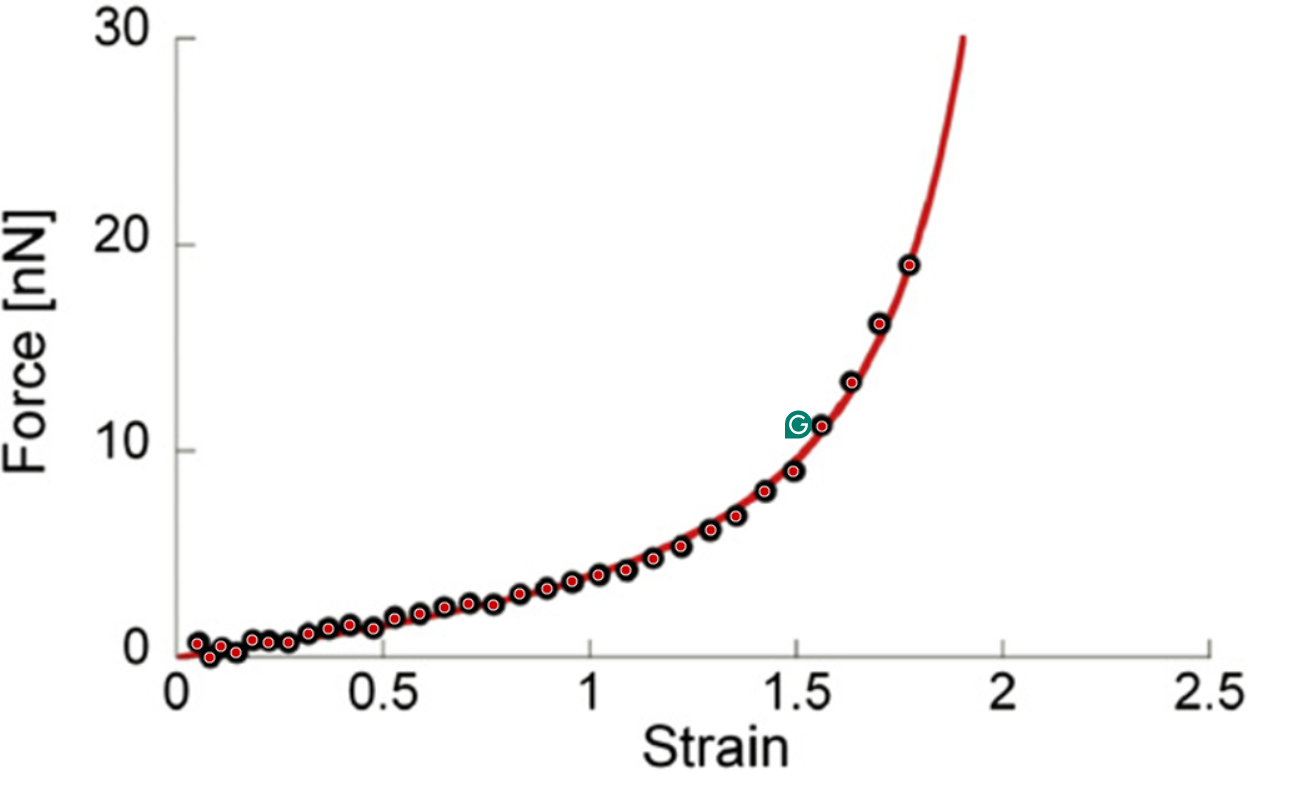

### Curve Fitting Using Least Squares Approximation

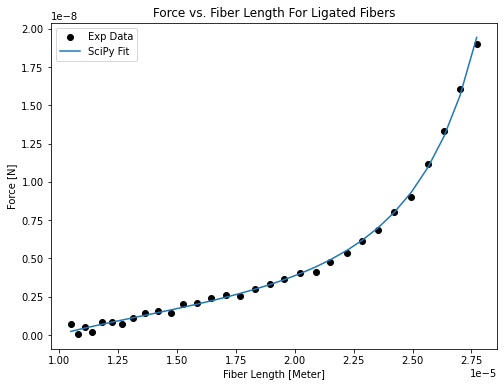

ligated Parameters:
A = 2.2186848058111795e-09
lm = 3.356389754487316e-05
kp = 1.1922356902864575e-19


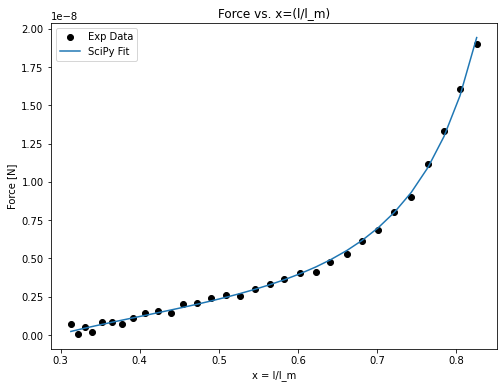

In [7]:
#Ligated Fibers

def f_l_Pow(l,A,l_m,k_p):
    return A*((1/4)*(1-(l/l_m))**(-2)-(1/4)+(l/l_m)) - (k_p/(l**2))

def f_x_Pow(x,A,l_m,k_p):
    return A*((1/4)*(1-(x))**(-2)-(1/4)+(x)) - (k_p/((x*l_m)**2))
    
Len_Data = np.array([[0.000010502958579881657, 7.100591715976321e-10],
[0.000010798816568047338, 6.325443786982224e-11],
[0.000011094674556213019, 5.325443786982224e-10],
[0.000011420118343195267, 1.7751479289940968e-10],
[0.000011804733727810652, 8.284023668639008e-10],
[0.000012248520710059173, 8.284023668639008e-10],
[0.000012692307692307693, 7.100591715976321e-10],
[0.000013136094674556214, 1.1242603550295858e-9],
[0.000013668639053254439, 1.4201183431952708e-9],
[0.000014201183431952665, 1.5384615384615395e-9],
[0.000014763313609467457, 1.4201183431952708e-9],
[0.000015266272189349116, 2.0118343195266276e-9],
[0.000015857988165680475, 2.0710059171597652e-9],
[0.000016449704142011837, 2.4260355029585813e-9],
[0.000017100591715976332, 2.603550295857991e-9],
[0.000017662721893491126, 2.5443786982248533e-9],
[0.00001831360946745562, 3.0177514792899447e-9],
[0.000018934911242603556, 3.313609467455623e-9],
[0.000019556213017751483, 3.668639053254439e-9],
[0.000020236686390532547, 4.023668639053255e-9],
[0.000020887573964497043, 4.1420118343195305e-9],
[0.000021508875739644973, 4.792899408284025e-9],
[0.000022218934911242606, 5.325443786982247e-9],
[0.000022869822485207106, 6.153846153846155e-9],
[0.000023550295857988167, 6.863905325443787e-9],
[0.000024230769230769234, 8.04733727810651e-9],
[0.000024940828402366867, 8.99408284023669e-9],
[0.0000256508875739645, 1.1183431952662727e-8],
[0.000026331360946745568, 1.3313609467455623e-8],
[0.000027011834319526633, 1.6094674556213024e-8],
[0.000027721893491124266, 1.899408284023669e-8]])

Len_Data_Fit = Len_Data*(1e+9); #Increasing the magnitude of the data for the curve fitter (Helps with error)

alpha_Pow = optimize.curve_fit(f_l_Pow, xdata = Len_Data_Fit[:,0] , ydata = Len_Data_Fit[:,1],p0 = [3,4e+4,1e+7])[0]; # Fit curve using least squares method

force_exp,ax = plt.subplots(1,1,figsize=(8,6))                          #plot the curve and the experimental data
plt.title("Force vs. Fiber Length For Ligated Fibers")
ax.set_xlabel("Fiber Length [Meter]")
ax.set_ylabel("Force [N]")
plt.scatter(Len_Data[:,0],Len_Data[:,1],color = 'black',label = 'Exp Data')
plt.plot(Len_Data[:,0], f_l_Pow(Len_Data[:,0],alpha_Pow[0]*1e-9,alpha_Pow[1]*1e-9,alpha_Pow[2]*1e-27),label='SciPy Fit') #Correct the magnitudes of the parameters
ax.legend()
plt.show()

print('ligated Parameters:')
A = alpha_Pow[0]*1e-9,
print('A = '+str(alpha_Pow[0]*1e-9))
l_m = alpha_Pow[1]*1e-9,
print('lm = '+str(alpha_Pow[1]*1e-9))
k_p = alpha_Pow[2]*1e-27,
print('kp = '+str(alpha_Pow[2]*1e-27))

#Define the function in terms of force vs x = l/lm
x_vect = Len_Data[:,0]/l_m;

x_data = np.vstack((x_vect,Len_Data[:,1]))

force_x,bx = plt.subplots(1,1,figsize=(8,6))                          
plt.title("Force vs. x=(l/l_m)")
bx.set_xlabel("x = l/l_m")
bx.set_ylabel("Force [N]")
plt.scatter(x_data[:][0],Len_Data[:,1],color = 'black',label = 'Exp Data')
plt.plot(x_data[:][0], f_x_Pow(x_data[:][0],A,l_m,k_p),label='SciPy Fit') #Correct the magnitudes of the parameters
bx.legend()
plt.show()
